<a href="https://colab.research.google.com/github/shristea7/College-Dump/blob/main/Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import heapq
from collections import deque
import random

random.seed(42)
np.random.seed(42)

In [ ]:
def generate_grid(rows, cols, num_goals=3, num_obstacles=5):
    grid = [['.' for _ in range(cols)] for _ in range(rows)]

    start = (random.randint(0, rows-1), random.randint(0, cols-1))
    grid[start[0]][start[1]] = 'S'

    while True:
        exit = (random.randint(0, rows-1), random.randint(0, cols-1))
        if exit != start:
            grid[exit[0]][exit[1]] = 'E'
            break

    goals_pos = set()
    goal_names = ['G'+str(i+1) for i in range(num_goals)]
    for name in goal_names:
        while True:
            g = (random.randint(0, rows-1), random.randint(0, cols-1))
            if g != start and g != exit and g not in goals_pos:
                grid[g[0]][g[1]] = name
                goals_pos.add(g)
                break

    for _ in range(num_obstacles):
        while True:
            obs = (random.randint(0, rows-1), random.randint(0, cols-1))
            if grid[obs[0]][obs[1]] == '.':
                grid[obs[0]][obs[1]] = '#'
                break
    return grid

In [ ]:
def bfs(grid, start, goals, exit):
    queue = deque()
    queue.append((start, frozenset(), [start]))
    visited = set()
    visited.add((start, frozenset()))

    while queue:
        position, collected, path = queue.popleft()
        if position in goals:
            collected = collected | {position}
        if position == exit and collected == goals:
            return path
        for move in get_neighbors(grid, position):
            state = (move, collected)
            if state not in visited:
                visited.add(state)
                queue.append((move, collected, path+[move]))
    return None

In [ ]:
def ucs(grid, start, goals, exit, goal_costs):
    pq = []
    heapq.heappush(pq, (0, start, frozenset(), [start]))
    visited = {}

    while pq:
        cost, position, collected, path = heapq.heappop(pq)
        if position in goals:
            collected = collected | {position}
        if position == exit and collected == goals:
            return path, cost
        for move in get_neighbors(grid, position):
            move_cost = 1 + goal_costs.get(grid[move[0]][move[1]], 0)
            state = (move, collected)
            total_cost = cost + move_cost
            if state not in visited or visited[state] > total_cost:
                visited[state] = total_cost
                heapq.heappush(pq, (total_cost, move, collected, path+[move]))
    return None, float('inf')

In [ ]:
def heuristic(position, collected, goals, exit):
    remaining = set(goals) - collected
    if not remaining:
        return manhattan(position, exit)
    nearest = min(remaining, key=lambda g: manhattan(position, g))
    return manhattan(position, nearest) + manhattan(nearest, exit)

def astar(grid, start, goals, exit, goal_costs):
    pq = []
    heapq.heappush(pq, (0 + heuristic(start, frozenset(), goals, exit), 0, start, frozenset(), [start]))
    visited = {}

    while pq:
        f, g, position, collected, path = heapq.heappop(pq)
        if position in goals:
            collected = collected | {position}
        if position == exit and collected == goals:
            return path, g
        for move in get_neighbors(grid, position):
            move_cost = 1 + goal_costs.get(grid[move[0]][move[1]], 0)
            total_g = g + move_cost
            state = (move, collected)
            if state not in visited or visited[state] > total_g:
                visited[state] = total_g
                heapq.heappush(pq, (total_g + heuristic(move, collected, goals, exit), total_g, move, collected, path+[move]))
    return None, float('inf')

In [ ]:
def visualize_path(grid, path):
    rows, cols = len(grid), len(grid[0])
    img = np.zeros((rows, cols, 3))

    color_map = {
        '.':[1,1,1],
        '#':[0,0,0],
        'S':[0,1,0],
        'E':[1,0,0],
        'G1':[1,1,0],
        'G2':[0,1,1],
        'G3':[1,0,1],
        'G4':[0.5,0,1],
        'G5':[1,0.5,0]
    }

    for r in range(rows):
        for c in range(cols):
            img[r,c] = color_map.get(grid[r][c],[0.8,0.8,0.8])

    fig, ax = plt.subplots()
    ax.imshow(img, interpolation='none')


    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)


    if path:
        path_r, path_c = zip(*path)
        ax.plot(path_c, path_r, color='blue', linewidth=2, marker='o')

    ax.set_xticks([])
    ax.set_yticks([])
    plt.title("Robot Path with Goals and Exit")
    plt.show()

In [ ]:
def analyze_paths_bfs_final(grid, paths, algorithms, goal_costs):
    col1, col2, col3, col4 = 18, 8, 16, 40
    header = f"{'Algorithm':<{col1}} | {'Steps':<{col2}} | {'Weighted Cost':<{col3}} | {'Goals Order':<{col4}}"
    print(header)
    print("-"*(col1 + col2 + col3 + col4 + 9))

    for i, path in enumerate(paths):
        algo = algorithms[i]

        if not path:
            steps = "No Path"
            total_cost = "Inf"
            goals_order = "-"
        else:
            steps = len(path) - 1
            goals_order_list = []

            if algo['weighted']:
                # UCS/A*: weighted cost
                total_cost = steps
                for pos in path:
                    cell = grid[pos[0]][pos[1]]
                    if cell.startswith('G') and cell not in goals_order_list:
                        goals_order_list.append(cell)
                        total_cost += goal_costs.get(cell, 0)
            else:
                # BFS: steps only, ignore weights completely
                total_cost = "-"
                for pos in path:
                    cell = grid[pos[0]][pos[1]]
                    if cell.startswith('G') and cell not in goals_order_list:
                        goals_order_list.append(cell)

            goals_order = " -> ".join(goals_order_list)

        print(f"{algo['name']:<{col1}} | {str(steps):<{col2}} | {str(total_cost):<{col3}} | {goals_order:<{col4}}")

Enter number of rows: 12
Enter number of columns: 12
Enter number of goals: 3
Enter number of obstacles: 24
# . . . . . . . . . . E
. # . # . . # . # . . .
. . . . . . . . . . . #
. . G2 . . # . . # . . .
# . # G1 . . . . . . . .
. . . . . # . . . . . .
. # . # . # . . . . . .
. . . . . . . . # # . .
. # . # . . . . . . . .
# . . . # . # . . . . .
. S . . . . . . . . . #
. G3 . . . . . . # . # .


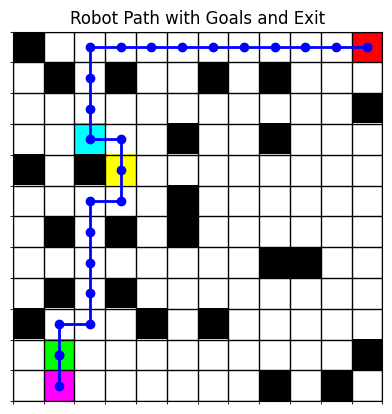

BFS


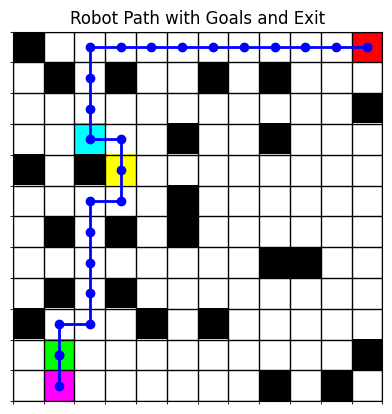

UCS cost: 24


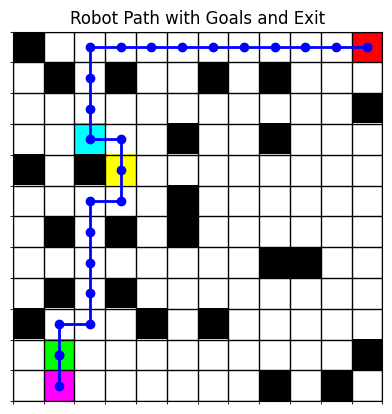

A* cost: 24
Algorithm          | Steps    | Weighted Cost    | Goals Order                             
-------------------------------------------------------------------------------------------
BFS (shortest)     | 24       | -                | G3 -> G1 -> G2                          
UCS (weighted)     | 24       | 24               | G3 -> G1 -> G2                          
A* (weighted)      | 24       | 24               | G3 -> G1 -> G2                          


In [ ]:
rows = int(input("Enter number of rows: "))
cols = int(input("Enter number of columns: "))
num_goals = int(input("Enter number of goals: "))
num_obstacles = int(input("Enter number of obstacles: "))# Generate random grid
grid = generate_grid(rows, cols, num_goals, num_obstacles)


# Print grid
for row in grid:
    print(' '.join(row))

# Find positions
start, goals, exit = find_positions(grid)

# Assign random weights for UCS/A*
goal_costs = {g: random.randint(1,5) for g in goals}

# Run BFS
path_bfs = bfs(grid, start, goals, exit)
visualize_path(grid, path_bfs)
print("BFS")

# Run UCS
path_ucs, cost_ucs = ucs(grid, start, goals, exit, goal_costs)
visualize_path(grid, path_ucs)
print("UCS cost:", cost_ucs)

# Run A*
path_astar, cost_astar = astar(grid, start, goals, exit, goal_costs)
visualize_path(grid, path_astar)
print("A* cost:", cost_astar)

paths = [path_bfs, path_ucs, path_astar]
algorithms = [
    {'name':'BFS (shortest)','weighted':False},
    {'name':'UCS (weighted)','weighted':True},
    {'name':'A* (weighted)','weighted':True}
]

analyze_paths_bfs_final(grid, paths, algorithms, goal_costs)